# BB84 Quantum Key Distribution (QKD) - Full Jupyter Notebook Implementation

This complete Jupyter notebook implements the **BB84 protocol** using **Qiskit 2.x**, fulfilling the **RPI QFF Hackathon prompt**.

**Features:**
- End-to-end key generation, sifting, QBER estimation
- **Eavesdropping simulation** (intercept-resend attack)
- **Circuit visualizations** (Alice, Bob, Eve)
- **Noise modeling** (depolarizing errors)
- **Metrics and plots** (QBER vs. noise/Eve)
- **Educational theory** in Markdown cells
- **Presentation slides** (exportable)

**Run Instructions:** `pip install qiskit qiskit-aer matplotlib numpy tabulate`

---

## 1. Background: Why QKD?

Classical public-key cryptography (RSA, ECC) relies on **computational hardness**.

**Quantum Threat:** Shor's algorithm breaks these on a large quantum computer.

**QKD Solution:** Uses **quantum mechanics** to generate keys with **information-theoretic security**.

**BB84 (1984):** Alice sends qubits in random bases → Bob measures → sift → detect Eve via **QBER**.

**Goal:** Simulate BB84, show eavesdropping detection, compare to post-quantum crypto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
import random
from tabulate import tabulate

np.random.seed(42)
random.seed(42)

## 2. Parameters

In [2]:
N_QUBITS = 10
BASES = ['Z', 'X']
THRESHOLD_QBER = 0.11

## 3. Alice: Key and Basis Generation

Alice generates:
- Random bits (0 or 1)
- Random bases (Z or X)

Encoding:
- Z-basis: `|0⟩` = 0, `|1⟩` = 1
- X-basis: `|+⟩` = H|0⟩, `|-⟩` = X H|0⟩

In [3]:
def alice_generate_key_and_bases(n_qubits):
    alice_bits = np.random.randint(0, 2, n_qubits).tolist()
    alice_bases = np.random.choice(BASES, n_qubits).tolist()
    return alice_bits, alice_bases

def alice_encode_circuit(alice_bits, alice_bases):
    qc = QuantumCircuit(N_QUBITS, N_QUBITS)
    z_indices_1 = [i for i, (b, basis) in enumerate(zip(alice_bits, alice_bases)) if basis == 'Z' and b == 1]
    x_indices = [i for i, basis in enumerate(alice_bases) if basis == 'X']
    x_indices_1 = [i for i, (b, basis) in enumerate(zip(alice_bits, alice_bases)) if basis == 'X' and b == 1]
    
    if z_indices_1:
        qc.x(z_indices_1)
    if x_indices:
        qc.h(x_indices)
    if x_indices_1:
        qc.x(x_indices_1)
    
    return qc

# Example
alice_bits, alice_bases = alice_generate_key_and_bases(N_QUBITS)
alice_qc = alice_encode_circuit(alice_bits, alice_bases)
print("Alice's bits:", alice_bits)
print("Alice's bases:", alice_bases)
alice_qc.draw('mpl')
plt.show()

Alice's bits: [0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
Alice's bases: ['Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'X', 'Z']


## 4. Bob: Measurement

Bob chooses random bases and measures.

- If X-basis → apply H before measuring in Z.

In [4]:
def bob_generate_bases(n_qubits):
    return np.random.choice(BASES, n_qubits).tolist()

def bob_measure_circuit(qc, bob_bases):
    x_indices = [i for i, basis in enumerate(bob_bases) if basis == 'X']
    if x_indices:
        qc.h(x_indices)
    qc.measure_all()
    return qc

# Example
bob_bases = bob_generate_bases(N_QUBITS)
print("Bob's bases:", bob_bases)

full_qc = alice_encode_circuit(alice_bits, alice_bases)
full_qc = bob_measure_circuit(full_qc, bob_bases)
full_qc.draw('mpl')
plt.show()

Bob's bases: ['X', 'Z', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'X']


## 5. Eavesdropping: Intercept-Resend Attack

Eve:
1. Measures in random basis
2. Resends qubit based on her result

→ Introduces **~25% QBER** in sifted key.

In [5]:
def eve_generate_bases(n_qubits):
    return np.random.choice(BASES, n_qubits).tolist()

def eve_intercept_circuit(qc, eve_bases):
    qc.barrier()
    for i in range(N_QUBITS):
        if eve_bases[i] == 'X':
            qc.h(i)
        qc.measure(i, i)
        qc.reset(i)
        if eve_bases[i] == 'Z':
            with qc.if_test((i, 1)):
                qc.x(i)
        else:
            qc.h(i)
            with qc.if_test((i, 1)):
                qc.x(i)
    qc.barrier()
    return qc

# Eve circuit
eve_bases = eve_generate_bases(N_QUBITS)
eve_qc = alice_encode_circuit(alice_bits, alice_bases)
eve_qc = eve_intercept_circuit(eve_qc, eve_bases)
eve_qc.draw('mpl', scale=0.8)
plt.show()

## 6. Simulation and Sifting

In [6]:
def simulate_circuit(qc, noise_level=0.0, shots=512):
    simulator = AerSimulator()
    
    if noise_level > 0:
        depol_error = depolarizing_error(noise_level, 1)
        noise_model = NoiseModel()
        noise_model.add_all_qubit_quantum_error(depol_error, ['h', 'x', 'measure'])
        t_qc = transpile(qc, simulator, optimization_level=0)
        result = simulator.run(t_qc, shots=shots, noise_model=noise_model, seed_simulator=42).result()
        counts = result.get_counts()
        bitstring = max(counts, key=counts.get)
    else:
        t_qc = transpile(qc, simulator, optimization_level=1)
        result = simulator.run(t_qc, shots=1).result()
        bitstring = list(result.get_counts().keys())[0]
    
    bitstring = bitstring.replace(' ', '')[-N_QUBITS:].zfill(N_QUBITS)[::-1]
    bob_bits = [int(bit) for bit in bitstring]
    assert len(bob_bits) == N_QUBITS
    return bob_bits

def sift_keys(alice_bits, bob_bits, alice_bases, bob_bases):
    match_mask = np.array(alice_bases) == np.array(bob_bases)
    sifted_alice = np.array(alice_bits)[match_mask].tolist()
    sifted_bob = np.array(bob_bits)[match_mask].tolist()
    return sifted_alice, sifted_bob, len(sifted_alice)

## 7. QBER Estimation

**QBER = (Mismatched bits in sample) / (Sample size)**

- Eve attack → ~25%
- Threshold: 11% → abort

In [7]:
def estimate_qber(sifted_alice, sifted_bob, sample_fraction=1.0):
    n_sample = int(len(sifted_alice) * sample_fraction)
    if n_sample == 0:
        return 0.0
    sample_idx = np.random.choice(len(sifted_alice), n_sample, replace=False)
    errors = np.sum(np.array(sifted_alice)[sample_idx] != np.array(sifted_bob)[sample_idx])
    return errors / n_sample

## 8. Full BB84 Run

Ideal:


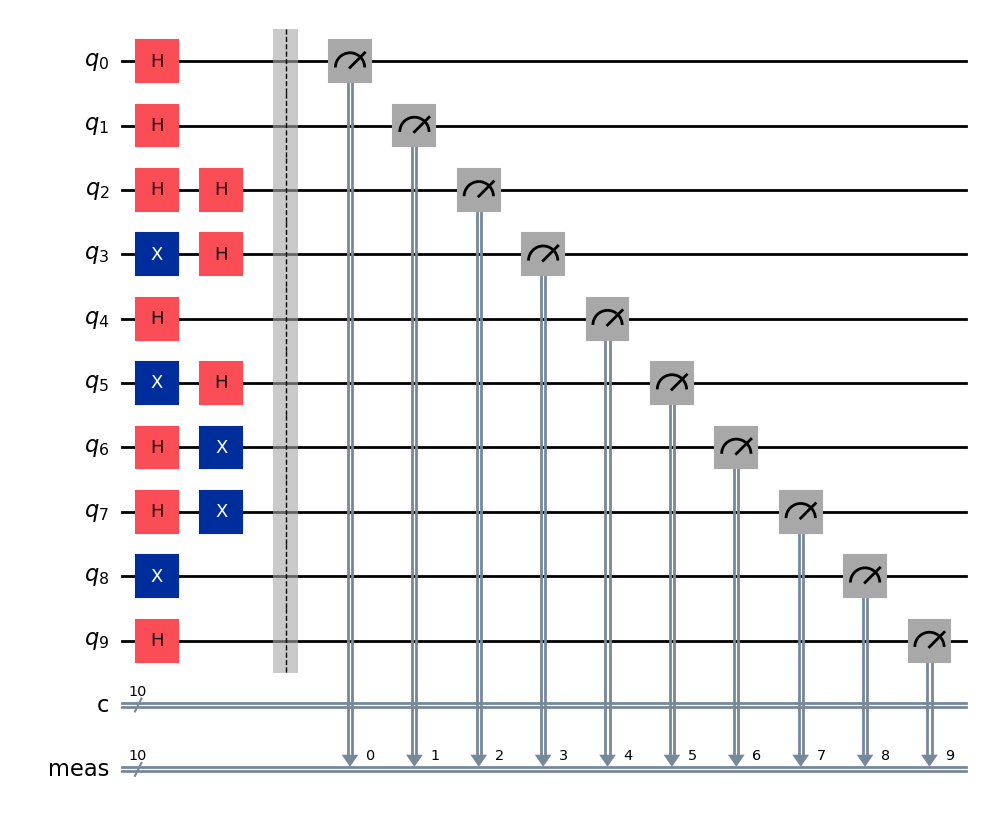

{'qber': np.float64(0.5), 'sifted_length': 2, 'final_key_length': 0, 'secure': np.False_}

Eve Attack:


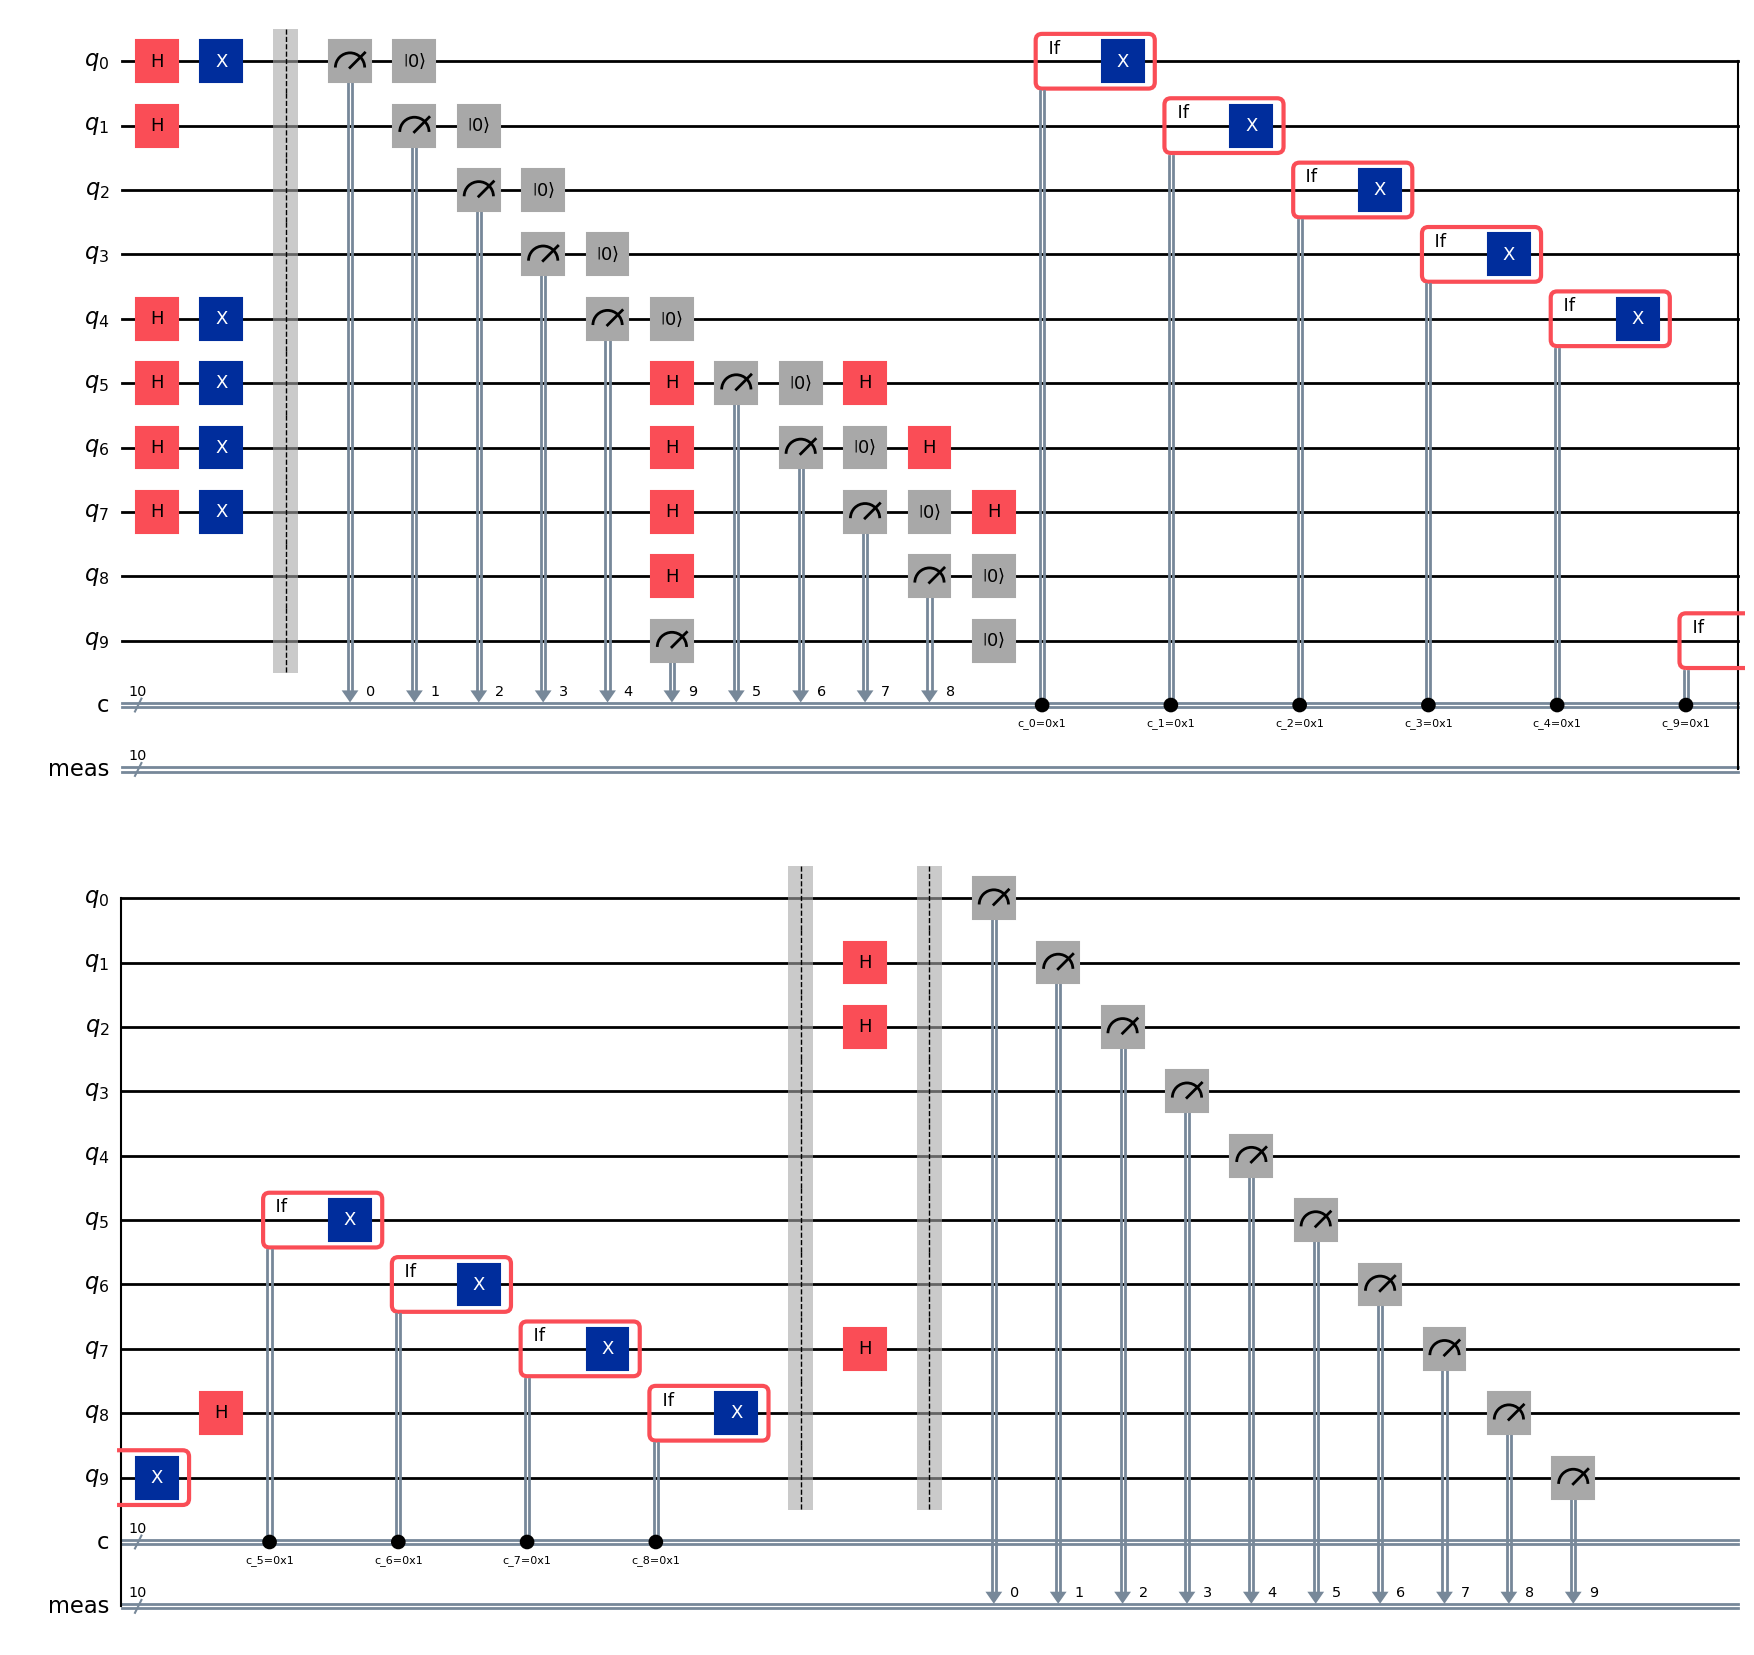

{'qber': np.float64(0.4), 'sifted_length': 5, 'final_key_length': 0, 'secure': np.False_}


In [12]:
def run_bb84(noise_level=0.0, eve_attack=False, n_qubits=10):
    alice_bits, alice_bases = alice_generate_key_and_bases(n_qubits)
    bob_bases = bob_generate_bases(n_qubits)
    
    full_qc = alice_encode_circuit(alice_bits, alice_bases)

    if eve_attack:
        eve_bases = eve_generate_bases(n_qubits)
        full_qc = eve_intercept_circuit(full_qc, eve_bases)
    
    full_qc = bob_measure_circuit(full_qc, bob_bases)
    
    display(full_qc.draw('mpl'))
    
    bob_bits = simulate_circuit(full_qc, noise_level)
    
    sifted_alice, sifted_bob, sifted_len = sift_keys(alice_bits, bob_bits, alice_bases, bob_bases)
    
    qber = estimate_qber(sifted_alice, sifted_bob)
    secure = qber < THRESHOLD_QBER
    final_key_len = sifted_len if secure else 0
    
    return {
        'qber': qber,
        'sifted_length': sifted_len,
        'final_key_length': final_key_len,
        'secure': secure
    }

# Examples
print("Ideal:")
result_ideal = run_bb84(0.0, False)
print(result_ideal)

print("\nEve Attack:")
result_eve = run_bb84(0.0, True)
print(result_eve)

## 9. Eavesdropping Experiments

+-------------+------------+-------------------+
| Scenario    |   Avg QBER |   Secure Fraction |
+=============+============+===================+
| No Attack   |      0.456 |              0.15 |
+-------------+------------+-------------------+
| Eve Attack  |      0.37  |              0.1  |
+-------------+------------+-------------------+
| Noisy + Eve |      0.419 |              0    |
+-------------+------------+-------------------+


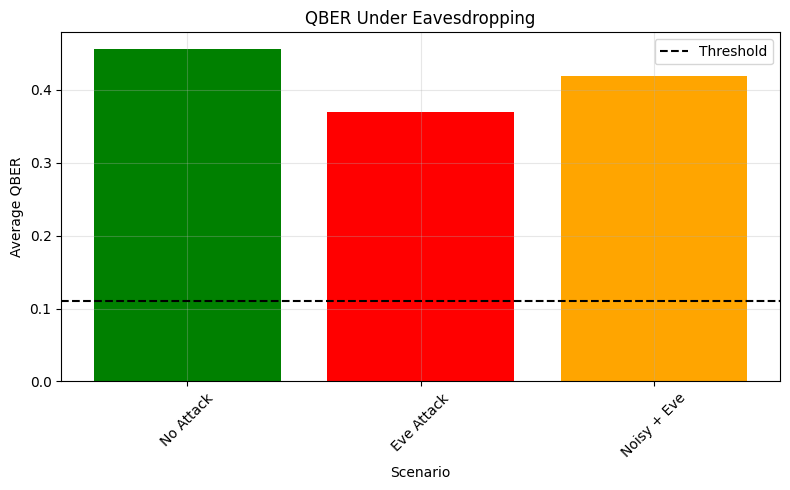

In [9]:
scenarios = [
    {'label': 'No Attack', 'noise': 0.0, 'eve': False},
    {'label': 'Eve Attack', 'noise': 0.0, 'eve': True},
    {'label': 'Noisy + Eve', 'noise': 0.05, 'eve': True}
]
trials = 20
exp_metrics = {scen['label']: {'qber': [], 'secure_fraction': []} for scen in scenarios}

for scen in scenarios:
    qbers, secures = [], []
    for _ in range(trials):
        res = run_bb84(scen['noise'], scen['eve'])
        qbers.append(res['qber'])
        secures.append(1 if res['secure'] else 0)
    exp_metrics[scen['label']]['qber'] = np.mean(qbers)
    exp_metrics[scen['label']]['secure_fraction'] = np.mean(secures)

# Table
results_table = [[scen['label'], f"{exp_metrics[scen['label']]['qber']:.3f}", f"{exp_metrics[scen['label']]['secure_fraction']:.3f}"] 
                 for scen in scenarios]
print(tabulate(results_table, headers=['Scenario', 'Avg QBER', 'Secure Fraction'], tablefmt='grid'))

# Bar plot
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(scenarios))
qbers = [exp_metrics[scen['label']]['qber'] for scen in scenarios]
plt.bar(x_pos, qbers, color=['green', 'red', 'orange'])
plt.axhline(THRESHOLD_QBER, color='black', linestyle='--', label='Threshold')
plt.xlabel('Scenario')
plt.ylabel('Average QBER')
plt.title('QBER Under Eavesdropping')
plt.xticks(x_pos, [scen['label'] for scen in scenarios], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Presentation: BB84 vs. ML-KEM (Kyber)

**Slide 1:** Title - BB84 QKD in 2025  
**Slide 2:** Quantum Threat  
**Slide 3:** QKD Fundamentals  
**Slide 4:** BB84 Mechanics + Eve = 25% QBER  
**Slide 5:** Prototype: Circuits + Plots  
**Slide 6:** Comparison Table  
**Slide 7:** 2025 Landscape  
**Slide 8:** Q&A

**Export:** `jupyter nbconvert --to slides this.ipynb --theme solarized`